### Connect postgresql database

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 数据库配置
username = "XXXXXX"
password = "YYYYYY"
host = "localhost"
port = 5432
database = "eyewear-data"

# 创建连接
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)


### Query and cal customer RFM feature

In [ ]:
# 1 查询并计算客户的RFM特征
customer_rfm_feature_sql = """
WITH customer_orders AS (
    SELECT 
        c.customer_id,
        c.total_orders,
        c.total_spend,
        c.total_spend / NULLIF(c.total_orders,0) AS avg_order_value,
        MAX(o.order_date) AS last_purchase_date,
        MIN(o.order_date) AS first_purchase_date,
        -- 是否购买过
        CASE WHEN COUNT(o.order_id) > 0 THEN 1 
        ELSE 0 END AS has_purchase,
        -- 是否复购客户
        CASE WHEN COUNT(o.order_id) >= 2 THEN 1 ELSE 0
        END AS repeat_customer_flag,
        CASE WHEN c.registration_date IS NOT NULL THEN COUNT(o.order_id)::float /
        NULLIF(DATE '2025-06-01'-c.registration_date, 0) ELSE 0 END AS purchase_frequency,
        CASE WHEN c.total_orders > 1 THEN (c.total_orders - 1.0) / NULLIF(c.total_orders, 0) 
        ELSE 0 END AS repeat_purchase_rate -- 复购率
    
    FROM "CustomerInfo" c
    LEFT JOIN "Order" o
        ON c.customer_id=o.customer_id
    AND o.order_status IN ('Completed', 'Shipped')
    LEFT JOIN (
        SELECT 
            customer_id,
            order_date,
            order_date - LAG(order_date) OVER (PARTITION BY customer_id ORDER BY order_date) AS order_interval_days
        FROM "Order"
    ) intervals 
        ON o.customer_id = intervals.customer_id 
        AND o.order_date = intervals.order_date
    WHERE o.order_status IN ('Completed','Shipped')
    OR o.order_id IS NULL          -- 保留没有订单的客户
    GROUP BY 
        c.customer_id,
        c.total_orders,
        c.total_spend,
        c.registration_date
)

SELECT 
    c.customer_id,
    c.registration_date,
    co.total_orders,
    co.total_spend,
    co.avg_order_value,
    co.first_purchase_date,
    co.last_purchase_date,
    co.purchase_frequency,
    co.repeat_customer_flag,
    co.has_purchase,
    co.repeat_purchase_rate,
    DATE '2025-06-01' - c.registration_date AS registration_days,
    DATE '2025-06-01' - c.last_purchase_date AS recency_days
FROM "CustomerInfo" c
LEFT JOIN customer_orders co ON c.customer_id = co.customer_id;
"""

df_rfm = pd.read_sql(customer_rfm_feature_sql, engine)

df_rfm

,customer_id,registration_date,total_orders,total_spend,avg_order_value,first_purchase_date,last_purchase_date,purchase_frequency,repeat_customer_flag,has_purchase,repeat_purchase_rate,registration_days,recency_days
0,1,2018-09-18,2,581.45,290.725000,2023-07-04 15:29:48,2023-11-08 17:19:27,0.000817,1,1,0.500000,2448,570.0
1,3,2017-07-20,1,434.35,434.350000,2023-07-21 00:27:06,2023-07-21 00:27:06,0.000348,0,1,0.000000,2873,680.0
2,7,2024-10-11,2,923.72,461.860000,2024-02-07 15:40:29,2024-06-05 14:57:23,0.008584,1,1,0.500000,233,359.0
3,13,2023-01-08,2,612.46,306.230000,2023-09-13 09:17:44,2024-11-18 12:25:53,0.002286,1,1,0.500000,875,194.0
4,14,2019-06-06,6,2209.77,368.295000,2023-05-02 16:02:36,2024-04-30 13:25:49,0.002743,1,1,0.833333,2187,397.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,159992,2024-03-10,6,2189.91,364.985000,2023-07-09 20:57:30,2024-07-27 21:22:33,0.013393,1,1,0.833333,448,307.0
159996,159994,2017-12-01,4,1736.47,434.117500,2023-06-24 15:58:27,2023-11-08 07:05:48,0.001460,1,1,0.750000,2739,571.0
159997,159995,2023-01-18,9,5819.59,646.621111,2023-03-10 18:01:33,2024-11-20 12:24:46,0.010405,1,1,0.888889,865,190.0
159998,159997,2017-03-14,6,2188.18,364.696667,2023-06-17 11:36:20,2024-12-10 15:05:23,0.001999,1,1,0.833333,3001,169.0


In [3]:
df_rfm.columns

Index(['customer_id', 'registration_date', 'total_orders', 'total_spend',
       'avg_order_value', 'first_purchase_date', 'last_purchase_date',
       'purchase_frequency', 'repeat_customer_flag', 'has_purchase',
       'repeat_purchase_rate', 'registration_days', 'recency_days'],
      dtype='object')

### Query and cal customer buying product feature

In [4]:
# 2 查询并计算客户购买Product的特征
customer_product_feature_sql = """
SELECT
    c.customer_id,
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS total_items,   
    -- 镜架类数量比例
    SUM(CASE WHEN  p.category IN ('Sunglasses','Eyeglasses','AI Glasses') AND oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::float / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) AS frame_ratio,
    -- 镜片数量比例
    SUM(CASE WHEN p.category='Lens' AND oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::float / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) AS lens_ratio,
    -- AI Glasses数量比例
    SUM(CASE WHEN p.category='AI Glasses' AND oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::float / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) AS ai_glasses_ratio,
    -- Sunglasses数量比例
    SUM(CASE WHEN p.category='Sunglasses' AND oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::float / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) AS sunglasses_ratio

FROM "CustomerInfo" c
LEFT JOIN "Order" o
ON c.customer_id=o.customer_id
LEFT JOIN "OrderItem" oi
ON o.order_id=oi.order_id
LEFT JOIN "ProductInfo" p
ON oi.product_id=p.product_id
WHERE o.order_status IN ('Completed','Shipped')
OR o.order_id IS NULL
GROUP BY c.customer_id;
"""

df_product = pd.read_sql(customer_product_feature_sql, engine)
df_product

,customer_id,total_items,frame_ratio,lens_ratio,ai_glasses_ratio,sunglasses_ratio
0,1,3,1.000000,0.000000,0.000000,0.666667
1,2,4,0.750000,0.250000,0.000000,0.500000
2,3,2,1.000000,0.000000,0.500000,0.000000
3,4,2,1.000000,0.000000,0.500000,0.000000
4,5,1,1.000000,0.000000,1.000000,0.000000
...,...,...,...,...,...,...
156963,159996,1,1.000000,0.000000,1.000000,0.000000
156964,159997,9,1.000000,0.000000,0.222222,0.444444
156965,159998,0,NaN,NaN,NaN,NaN
156966,159999,6,0.833333,0.166667,0.333333,0.500000


### Query and cal customer attend promotion feature

In [5]:
# 3 查询并计算客户参加的促销特征
customer_promotion_feature_sql = """
SELECT
    -- 平均折扣
    c.customer_id,
    -- 平均优惠比例
    1 - AVG(NULLIF(oi.discount_rate,0)) AS avg_discount_percentage,
    -- 使用优惠商品比例（排除赠品）
    AVG(CASE WHEN oi.is_free_gift=False AND oi.discount_rate < 1 THEN 1 ELSE 0 END) AS discount_usage_rate, 
    -- 促销订单比例
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END)::float / NULLIF(COUNT(DISTINCT o.order_id), 0) AS promo_order_ratio

FROM "CustomerInfo" c
LEFT JOIN "Order" o
ON c.customer_id=o.customer_id
LEFT JOIN "OrderItem" oi
ON o.order_id=oi.order_id
WHERE o.order_status IN ('Completed','Shipped') OR o.order_id IS NULL
GROUP BY c.customer_id;
"""

df_promo = pd.read_sql(customer_promotion_feature_sql, engine)

df_promo

,customer_id,avg_discount_percentage,discount_usage_rate,promo_order_ratio
0,1,0.120000,0.666667,0.500000
1,2,0.000000,0.000000,0.000000
2,3,0.000000,0.000000,1.000000
3,4,0.000000,0.000000,0.000000
4,5,0.180000,1.000000,1.000000
...,...,...,...,...
156963,159996,0.000000,0.000000,0.000000
156964,159997,0.042857,0.142857,0.166667
156965,159998,NaN,0.000000,NaN
156966,159999,0.090000,0.500000,0.500000


### Merge 3 dataframes into a complete dataframe

In [6]:
df_all_customer_feature = (
    df_rfm
    .merge(df_product,
           on="customer_id",
           how="left")
    .merge(df_promo,
           on="customer_id",
           how="left")
)

df_has_purchase_customer = df_all_customer_feature[df_all_customer_feature.has_purchase==1].copy()
df_has_purchase_customer

,customer_id,registration_date,total_orders,total_spend,avg_order_value,first_purchase_date,last_purchase_date,purchase_frequency,repeat_customer_flag,has_purchase,...,registration_days,recency_days,total_items,frame_ratio,lens_ratio,ai_glasses_ratio,sunglasses_ratio,avg_discount_percentage,discount_usage_rate,promo_order_ratio
0,1,2018-09-18,2,581.45,290.725000,2023-07-04 15:29:48,2023-11-08 17:19:27,0.000817,1,1,...,2448,570.0,3.0,1.000000,0.000000,0.000000,0.666667,0.120000,0.666667,0.500000
1,3,2017-07-20,1,434.35,434.350000,2023-07-21 00:27:06,2023-07-21 00:27:06,0.000348,0,1,...,2873,680.0,2.0,1.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000
2,7,2024-10-11,2,923.72,461.860000,2024-02-07 15:40:29,2024-06-05 14:57:23,0.008584,1,1,...,233,359.0,4.0,1.000000,0.000000,0.500000,0.250000,0.000000,0.000000,0.500000
3,13,2023-01-08,2,612.46,306.230000,2023-09-13 09:17:44,2024-11-18 12:25:53,0.002286,1,1,...,875,194.0,2.0,1.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000
4,14,2019-06-06,6,2209.77,368.295000,2023-05-02 16:02:36,2024-04-30 13:25:49,0.002743,1,1,...,2187,397.0,8.0,0.875000,0.125000,0.375000,0.125000,0.025000,0.125000,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,159992,2024-03-10,6,2189.91,364.985000,2023-07-09 20:57:30,2024-07-27 21:22:33,0.013393,1,1,...,448,307.0,8.0,0.750000,0.250000,0.125000,0.250000,0.077500,0.625000,0.500000
159996,159994,2017-12-01,4,1736.47,434.117500,2023-06-24 15:58:27,2023-11-08 07:05:48,0.001460,1,1,...,2739,571.0,7.0,0.714286,0.285714,0.428571,0.142857,0.085714,0.428571,0.250000
159997,159995,2023-01-18,9,5819.59,646.621111,2023-03-10 18:01:33,2024-11-20 12:24:46,0.010405,1,1,...,865,190.0,23.0,0.826087,0.173913,0.347826,0.217391,0.107647,0.411765,0.444444
159998,159997,2017-03-14,6,2188.18,364.696667,2023-06-17 11:36:20,2024-12-10 15:05:23,0.001999,1,1,...,3001,169.0,9.0,1.000000,0.000000,0.222222,0.444444,0.042857,0.142857,0.166667


In [7]:
df_has_purchase_customer.shape
df_has_purchase_customer.columns

Index(['customer_id', 'registration_date', 'total_orders', 'total_spend',
       'avg_order_value', 'first_purchase_date', 'last_purchase_date',
       'purchase_frequency', 'repeat_customer_flag', 'has_purchase',
       'repeat_purchase_rate', 'registration_days', 'recency_days',
       'total_items', 'frame_ratio', 'lens_ratio', 'ai_glasses_ratio',
       'sunglasses_ratio', 'avg_discount_percentage', 'discount_usage_rate',
       'promo_order_ratio'],
      dtype='object')

In [8]:
df_has_purchase_customer[
    "avg_discount_percentage"
].isnull().sum()

np.int64(0)

In [9]:
df_has_purchase_customer["avg_discount_percentage"].describe()

count    149999.000000
mean          0.064328
std           0.070767
min           0.000000
25%           0.000000
50%           0.047500
75%           0.104286
max           0.350000
Name: avg_discount_percentage, dtype: float64

In [10]:
# 处理目标列的缺失值
time_features = ["registration_days", "recency_days"]

normal_features = [
    "total_orders", "total_spend", "avg_order_value",
    "purchase_frequency", "repeat_customer_flag", "has_purchase",
    "repeat_purchase_rate",
    "total_items", "frame_ratio", "lens_ratio",
    "ai_glasses_ratio", "sunglasses_ratio",
    "avg_discount_percentage", "discount_usage_rate", "promo_order_ratio"
]

X_normal = df_has_purchase_customer[normal_features].copy()
X_normal = X_normal.fillna(0)

# # 2. recency_days 缺失值填最大值
X_time = df_has_purchase_customer[time_features].copy()
max_recency = X_time["recency_days"].max(skipna=True)
if pd.isna(max_recency):
    max_recency = 0
X_time["recency_days"] = X_time["recency_days"].fillna(max_recency)

for col in time_features:
    if pd.api.types.is_timedelta64_dtype(X_time[col]):
        X_time[col] = X_time[col].dt.total_seconds() / 86400

# 如果你后面只想对 normal_features 聚类，就用 X_normal
# 如果你想把 time_features 也一起纳入聚类，再合并：
X = pd.concat([X_normal, X_time], axis=1)
X



,total_orders,total_spend,avg_order_value,purchase_frequency,repeat_customer_flag,has_purchase,repeat_purchase_rate,total_items,frame_ratio,lens_ratio,ai_glasses_ratio,sunglasses_ratio,avg_discount_percentage,discount_usage_rate,promo_order_ratio,registration_days,recency_days
0,2,581.45,290.725000,0.000817,1,1,0.500000,3.0,1.000000,0.000000,0.000000,0.666667,0.120000,0.666667,0.500000,2448,570.0
1,1,434.35,434.350000,0.000348,0,1,0.000000,2.0,1.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,2873,680.0
2,2,923.72,461.860000,0.008584,1,1,0.500000,4.0,1.000000,0.000000,0.500000,0.250000,0.000000,0.000000,0.500000,233,359.0
3,2,612.46,306.230000,0.002286,1,1,0.500000,2.0,1.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,875,194.0
4,6,2209.77,368.295000,0.002743,1,1,0.833333,8.0,0.875000,0.125000,0.375000,0.125000,0.025000,0.125000,0.166667,2187,397.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,6,2189.91,364.985000,0.013393,1,1,0.833333,8.0,0.750000,0.250000,0.125000,0.250000,0.077500,0.625000,0.500000,448,307.0
159996,4,1736.47,434.117500,0.001460,1,1,0.750000,7.0,0.714286,0.285714,0.428571,0.142857,0.085714,0.428571,0.250000,2739,571.0
159997,9,5819.59,646.621111,0.010405,1,1,0.888889,23.0,0.826087,0.173913,0.347826,0.217391,0.107647,0.411765,0.444444,865,190.0
159998,6,2188.18,364.696667,0.001999,1,1,0.833333,9.0,1.000000,0.000000,0.222222,0.444444,0.042857,0.142857,0.166667,3001,169.0


In [11]:
X.isna().sum()

total_orders               0
total_spend                0
avg_order_value            0
purchase_frequency         0
repeat_customer_flag       0
has_purchase               0
repeat_purchase_rate       0
total_items                0
frame_ratio                0
lens_ratio                 0
ai_glasses_ratio           0
sunglasses_ratio           0
avg_discount_percentage    0
discount_usage_rate        0
promo_order_ratio          0
registration_days          0
recency_days               0
dtype: int64

In [12]:
X.dtypes

total_orders                 int64
total_spend                float64
avg_order_value            float64
purchase_frequency         float64
repeat_customer_flag         int64
has_purchase                 int64
repeat_purchase_rate       float64
total_items                float64
frame_ratio                float64
lens_ratio                 float64
ai_glasses_ratio           float64
sunglasses_ratio           float64
avg_discount_percentage    float64
discount_usage_rate        float64
promo_order_ratio          float64
registration_days            int64
recency_days               float64
dtype: object

In [13]:
# 归一化/标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.6197915 , -0.83670666, -0.7152703 , ...,  0.50770349,
         0.4153987 ,  1.18291094],
       [-1.26403878, -1.00641295, -0.03338223, ...,  2.06748475,
         0.81856945,  1.80239268],
       [-0.6197915 , -0.44183668,  0.09722693, ...,  0.50770349,
        -1.68583236, -0.00536768],
       ...,
       [ 3.88993952,  5.20642948,  0.97441682, ...,  0.33439446,
        -1.08629375, -0.9571169 ],
       [ 1.95719765,  1.01694524, -0.3640752 , ..., -0.53215069,
         0.93999499, -1.0753816 ],
       [-1.26403878, -1.05034508, -0.21417456, ..., -1.05207778,
        -0.28279817, -0.6980609 ]], shape=(149999, 17))

   PC  Variance_Explained  Cumulative_Variance
0   1            0.276023             0.276023
1   2            0.181068             0.457091
2   3            0.135896             0.592986
3   4            0.096013             0.688999
4   5            0.091930             0.780929
5   6            0.080791             0.861720
6   7            0.041294             0.903014
7   8            0.035339             0.938353
8   9            0.024790             0.963143
9  10            0.018084             0.981228


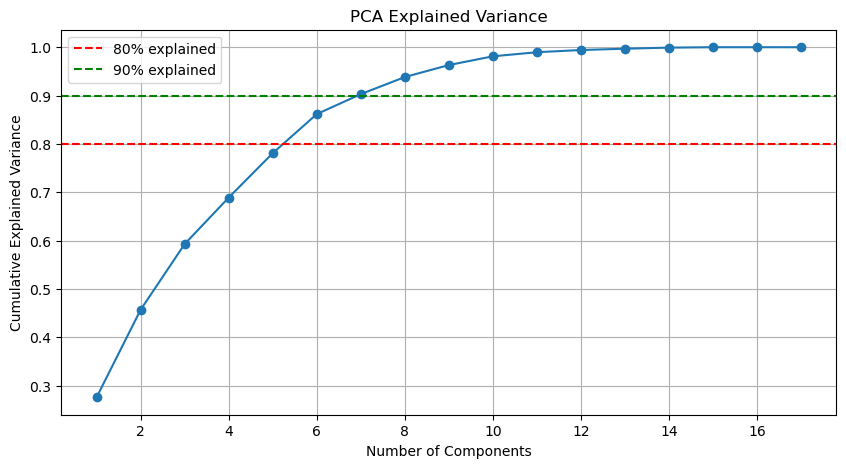

In [14]:
# PCA
# 在 X_scaled 生成之后立即插入
from sklearn.decomposition import PCA

# 先拟合完整的 PCA 看解释率
pca = PCA()
pca.fit(X_scaled)

# 查看每个主成分的解释率
explained_variance = pd.DataFrame({
    'PC': range(1, len(pca.explained_variance_ratio_) + 1),
    'Variance_Explained': pca.explained_variance_ratio_,
    'Cumulative_Variance': pca.explained_variance_ratio_.cumsum()
})
print(explained_variance.head(10))

# 画解释率曲线
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% explained')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid()
plt.show()


### Generate the final cluster label

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42) # K=5的情况
df_has_purchase_customer["cluster"] = kmeans.fit_predict(X_scaled)
df_has_purchase_customer

d:\miniconda_envs\junliangvenv1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,customer_id,registration_date,total_orders,total_spend,avg_order_value,first_purchase_date,last_purchase_date,purchase_frequency,repeat_customer_flag,has_purchase,...,recency_days,total_items,frame_ratio,lens_ratio,ai_glasses_ratio,sunglasses_ratio,avg_discount_percentage,discount_usage_rate,promo_order_ratio,cluster
0,1,2018-09-18,2,581.45,290.725000,2023-07-04 15:29:48,2023-11-08 17:19:27,0.000817,1,1,...,570.0,3.0,1.000000,0.000000,0.000000,0.666667,0.120000,0.666667,0.500000,0
1,3,2017-07-20,1,434.35,434.350000,2023-07-21 00:27:06,2023-07-21 00:27:06,0.000348,0,1,...,680.0,2.0,1.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,1
2,7,2024-10-11,2,923.72,461.860000,2024-02-07 15:40:29,2024-06-05 14:57:23,0.008584,1,1,...,359.0,4.0,1.000000,0.000000,0.500000,0.250000,0.000000,0.000000,0.500000,4
3,13,2023-01-08,2,612.46,306.230000,2023-09-13 09:17:44,2024-11-18 12:25:53,0.002286,1,1,...,194.0,2.0,1.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,4
4,14,2019-06-06,6,2209.77,368.295000,2023-05-02 16:02:36,2024-04-30 13:25:49,0.002743,1,1,...,397.0,8.0,0.875000,0.125000,0.375000,0.125000,0.025000,0.125000,0.166667,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,159992,2024-03-10,6,2189.91,364.985000,2023-07-09 20:57:30,2024-07-27 21:22:33,0.013393,1,1,...,307.0,8.0,0.750000,0.250000,0.125000,0.250000,0.077500,0.625000,0.500000,3
159996,159994,2017-12-01,4,1736.47,434.117500,2023-06-24 15:58:27,2023-11-08 07:05:48,0.001460,1,1,...,571.0,7.0,0.714286,0.285714,0.428571,0.142857,0.085714,0.428571,0.250000,4
159997,159995,2023-01-18,9,5819.59,646.621111,2023-03-10 18:01:33,2024-11-20 12:24:46,0.010405,1,1,...,190.0,23.0,0.826087,0.173913,0.347826,0.217391,0.107647,0.411765,0.444444,3
159998,159997,2017-03-14,6,2188.18,364.696667,2023-06-17 11:36:20,2024-12-10 15:05:23,0.001999,1,1,...,169.0,9.0,1.000000,0.000000,0.222222,0.444444,0.042857,0.142857,0.166667,3


### export customer cluster data

In [16]:
df_has_purchase_customer.to_parquet(
    "customerinfo_cluster.parquet",
    index=False
)

In [ ]:
# 每个cluster的大小
df_has_purchase_customer["cluster"].value_counts()

cluster
4    53975
3    37480
0    29349
1    16774
2    12421
Name: count, dtype: int64

In [27]:
len(df_has_purchase_customer), X_scaled.shape[0]

(149999, 149999)

### cluster stability test

In [23]:
from sklearn.metrics import adjusted_rand_score

labels_ref = kmeans.labels_

aris = []
for seed in [0, 7, 42, 99, 123]:
    km = KMeans(n_clusters=5, random_state=seed, n_init=20)
    labels = km.fit_predict(X_scaled)
    aris.append(adjusted_rand_score(labels_ref, labels))

print("ARI:", aris)
print("平均 ARI:", sum(aris) / len(aris))

ARI: [0.9961127322453507, 0.9994830014061812, 0.9978609837688304, 0.9978563114344007, 0.9979453200663769]
平均 ARI: 0.9978516697842279


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

base_labels = df_has_purchase_customer["cluster"].values
ari_scores = []

for i in range(10):
    # 随机抽80%客户
    sample_idx = np.random.choice(
        len(X_scaled),
        size=int(len(X_scaled)*0.8),
        replace=False
    )
    X_sample = X_scaled[sample_idx]
    kmeans_boot = KMeans(
        n_clusters=5,
        random_state=42,
        n_init=20
    )
    sample_labels = kmeans_boot.fit_predict(
        X_sample
    )
    # 和原始聚类比较
    ari = adjusted_rand_score(
        base_labels[sample_idx],
        sample_labels
    )
    ari_scores.append(ari)

print("Mean ARI:", np.mean(ari_scores))
print("Std ARI:", np.std(ari_scores))

Mean ARI: 0.9946866872799636
Std ARI: 0.001984104384344773


### Determining the best Number of Clusters k

In [19]:
# 确定最佳簇数 k
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42,n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels,sample_size=10000, random_state=42))

result = pd.DataFrame({"k": list(K), "inertia": inertia, "silhouette": silhouette})
result

,k,inertia,silhouette
0,2,1.965268e+06,0.304079
1,3,1.714938e+06,0.176475
2,4,1.555748e+06,0.188976
3,5,1.400068e+06,0.164126
4,6,1.311202e+06,0.165352
5,7,1.209500e+06,0.175714
6,8,1.171113e+06,0.153685


In [20]:
# 生成 cluster_profile

cluster_profile = (
    df_has_purchase_customer
    .groupby("cluster")
    [
        [
            "total_orders",
            "total_spend",
            "avg_order_value",
            "purchase_frequency",
            "recency_days",
            "total_items",
            "frame_ratio",
            "lens_ratio",
            "ai_glasses_ratio",
            "sunglasses_ratio",
            "avg_discount_percentage",
            "promo_order_ratio"
        ]
    ]
    .mean()
)

cluster_profile

,total_orders,total_spend,avg_order_value,purchase_frequency,recency_days,total_items,frame_ratio,lens_ratio,ai_glasses_ratio,sunglasses_ratio,avg_discount_percentage,promo_order_ratio
cluster,,,,,,,,,,,,
0,2.146410,742.088759,351.415156,0.001641,380.886845,3.110736,0.936688,0.063312,0.355364,0.289179,0.166960,0.762377
1,1.000000,487.833425,487.833425,0.000835,514.778288,1.670800,0.973112,0.026888,0.347468,0.312388,0.000018,0.040062
2,2.086789,779.914513,376.372911,0.001651,437.676194,2.965864,0.346111,0.653889,0.111809,0.102755,0.057141,0.301762
3,4.871958,2418.086440,517.055262,0.004767,265.507444,8.771878,0.860508,0.139492,0.323492,0.266052,0.064577,0.354916
4,2.890468,1217.676095,438.276705,0.002023,348.151459,4.388254,0.911017,0.088983,0.322541,0.296504,0.029989,0.194349


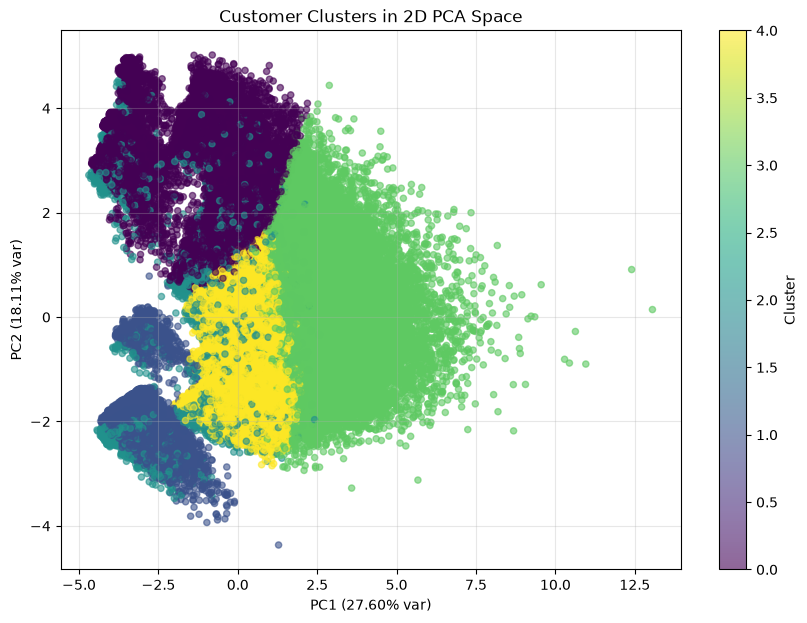

前2个主成分共解释 45.71% 的方差


In [ ]:
# 数据可视化
# 降到 2D 用于可视化
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# 画PCA散点图
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=df_has_purchase_customer['cluster'], 
                      cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)')
plt.title('Customer Clusters in 2D PCA Space')
plt.grid(alpha=0.3)
plt.show()

print(f"前2个主成分共解释 {pca_2d.explained_variance_ratio_.sum():.2%} 的方差")

In [36]:
# 统计每个cluster业务指标（版本1）

cluster_summary = (
    df_has_purchase_customer
    .groupby("cluster")
    .agg(
        customer_count=("customer_id", "count"),
        total_spend=("total_spend", "sum"),
        avg_spend=("total_spend", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_purchase_frequency=("purchase_frequency", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_repeat_rate=("repeat_purchase_rate", "mean"),
        avg_discount_percentage=("avg_discount_percentage", "mean"),
        avg_promo_order_ratio=("promo_order_ratio", "mean"),
        avg_total_items=("total_items", "mean"),
        avg_frame_ratio=("frame_ratio", "mean"),
        avg_lens_ratio=("lens_ratio", "mean"),
        avg_ai_glasses_ratio=("ai_glasses_ratio", "mean"),
        avg_sunglasses_ratio=("sunglasses_ratio", "mean"),
    )
    .reset_index()
)

cluster_summary["customer_share"] = (
    cluster_summary.customer_count /
    cluster_summary.customer_count.sum()
)


cluster_summary["revenue_share"] = (
    cluster_summary.total_spend /
    cluster_summary.total_spend.sum()
)

cluster_summary

,cluster,customer_count,total_spend,avg_spend,avg_order_value,avg_purchase_frequency,avg_recency_days,avg_repeat_rate,avg_discount_percentage,avg_promo_order_ratio,avg_total_items,avg_frame_ratio,avg_lens_ratio,avg_ai_glasses_ratio,avg_sunglasses_ratio,customer_share,revenue_share
0,0,29349,21779562.98,742.088759,351.415156,0.001641,380.886845,0.431376,0.166960,0.762377,3.110736,0.936688,0.063312,0.355364,0.289179,0.195661,0.111118
1,1,16774,8182917.87,487.833425,487.833425,0.000835,514.778288,0.000000,0.000018,0.040062,1.670800,0.973112,0.026888,0.347468,0.312388,0.111827,0.041749
2,2,12421,9687318.16,779.914513,376.372911,0.001651,437.676194,0.417944,0.057141,0.301762,2.965864,0.346111,0.653889,0.111809,0.102755,0.082807,0.049424
3,3,37480,90629879.77,2418.086440,517.055262,0.004767,265.507444,0.780346,0.064577,0.354916,8.771878,0.860508,0.139492,0.323492,0.266052,0.249868,0.462389
4,4,53975,65724067.25,1217.676095,438.276705,0.002023,348.151459,0.626436,0.029989,0.194349,4.388254,0.911017,0.088983,0.322541,0.296504,0.359836,0.335320


### data vis 1

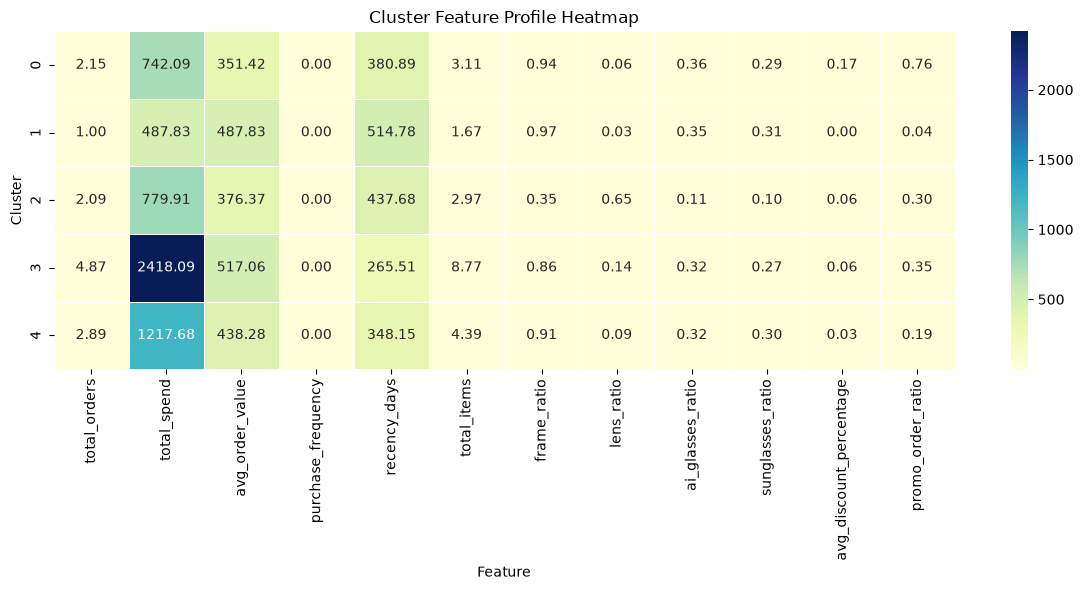

In [37]:
# 数据可视化还可以做：Radar map / heat map

import seaborn as sns
import matplotlib.pyplot as plt

# 如果你用的是 cluster_profile
profile = cluster_profile.copy()

plt.figure(figsize=(12, 6))
sns.heatmap(
    profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Cluster Feature Profile Heatmap")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### data vis 2

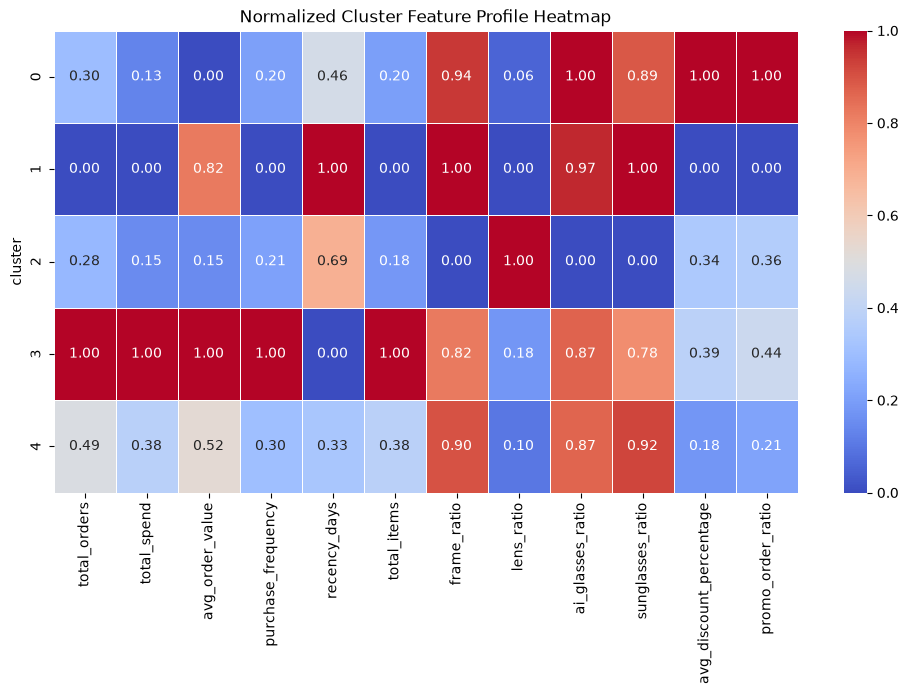

In [38]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(12, 6))
sns.heatmap(
    profile_norm,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Normalized Cluster Feature Profile Heatmap")
plt.show()

### data vis 3

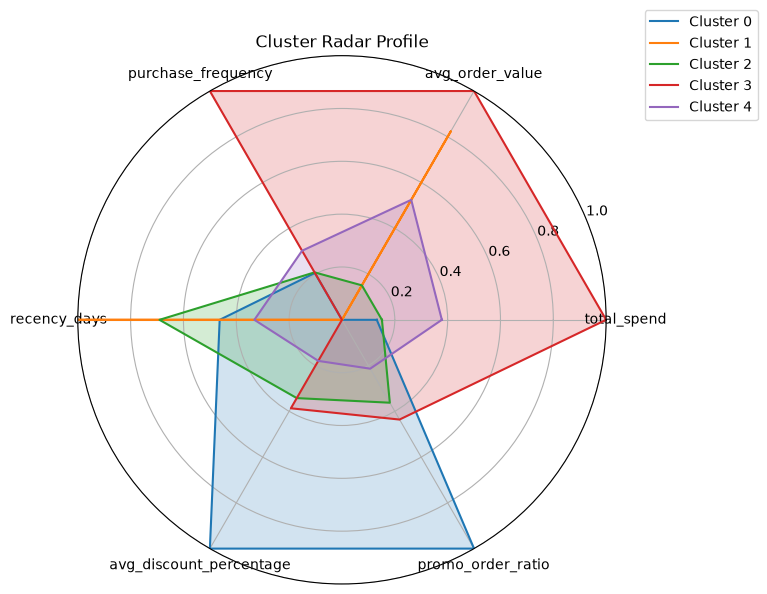

In [39]:
import numpy as np
import matplotlib.pyplot as plt

features = [
    "total_spend", "avg_order_value", "purchase_frequency",
    "recency_days", "avg_discount_percentage", "promo_order_ratio"
]

radar_data = cluster_profile[features].copy()

# 归一化到 0-1，避免量纲差异
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

labels = radar_norm.columns.tolist()
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id, row in radar_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f"Cluster {cluster_id}")
    ax.fill(angles, values, alpha=0.2)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.set_title("Cluster Radar Profile")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()